In [10]:
#!/usr/bin/env python3
import os
import scipy.io as sio
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
from scipy.stats import f_oneway

# 1. Full list of session paths (your comprehensive list)
session_paths = [
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_clearsrealmouse_14_32",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_clearsrealmouse_14_56",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_clearfakemouse_14_32",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_blue_15_41",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_blue_13_49",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_pink_13_59",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_clear_16_47",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_pink_16_00",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_orange_16_23",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_clear_14_20",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_orange_14_10",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_origgreen_13_32",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_origgreen_15_29",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_clear_16_33",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_clearfakemouse_15_11",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_orange_16_23",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_origgreen_14_20",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_pink_16_13",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_blue_16_03",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_clearfakemouse_16_46",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_clearsrealmouse_16_58",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_clearsrealmouse_15_31",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_clear_15_11",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_blue_14_33",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_pink_14_48",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_orange_15_00",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_origgreen_15_52",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_17/20250407V1L23r1blkcap_econeafterscone",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_17/20250505V1L23R1pink_sconeF",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_17/20250407V1L23r1blkcap",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_17/20250505V1L23R1pink_scone",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_17/20250505V1L23R1pink_econe",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_17/20250505V1L23R1pink_econeafterscone",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_17/20250407V1L23r1blkcap_econe",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_26/20250505v1l23r1_ecups",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_26/20250505v1l23r1_greencupsocial2",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_26/20250505v1l23r1_greencupsocial",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_26/20250506v1l23l1_clearsocialcup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_26/20250506v1l23l1_greensocialcup_mini",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_26/20250506v1l23l1_greensocialcup2",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_26/20250506v1l23l1_greensocialcup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_24/20250519PMCL23L2_enewcone_econe_oldecone",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_24/20250519PMCL23L2_enewcone",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250324pmcl23_clearecup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_clearscup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250303pmcsurface_greenecup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250324pmcl23_greenscup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_greenecup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250324pmcl23_clearscup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_clearecup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_25/20250407v1l23_socialclearcup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_25/20250407v1l23_socialblackcup_2",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_06_25/20250407v1l23_socialblackcup",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_02/20250407v1l23"
]


# 2. Cup‐parsing patterns (unchanged)
cond_patterns = sorted(
    ["clearfakemouse", "clearsrealmouse", "origgreen", "blue",
     "orange", "pink", "clear"],
    key=len, reverse=True
)

def parse_metadata(path):
    session = os.path.basename(path)
    date    = os.path.basename(os.path.dirname(path))
    animal  = session.split("_", 1)[0]
    cup     = next((c for c in cond_patterns if c in session), "unknown")
    parts   = session.split("_")
    time    = f"{parts[-2]}:{parts[-1]}" if len(parts) >= 2 else "00:00"
    return animal, cup, date, time

# 3. New classification into three conditions
def classify_condition(session_name, cup):
    s = session_name.lower()

    # drop any partner runs
    if "partner" in s:
        return None

    # social: clearsrealmouse or explicit social‐cone/cup tags
    if cup == "clearsrealmouse" \
       or "_scone" in s     \
       or "_scup" in s      \
       or "_social" in s:
        return "social"

    # nonsocial: empty‐cone, empty‐cup, or any other cup category
    if "econe" in s \
       or "ecup" in s \
       or cup in [
         "clearfakemouse",
         "origgreen",
         "blue",
         "orange",
         "pink",
         "clear"
       ]:
        return "nonsocial"

    # single‐run (no underscore at all)
    if "_" not in session_name:
        return "single"

    # anything else gets skipped
    return None


records = []
skipped = []

for p in session_paths:
    name = os.path.basename(p)
    animal, cup, date, time = parse_metadata(p)
    cond = classify_condition(name, cup)
    if cond is None:
        skipped.append(p)
        continue

    animal, cup, date, time = parse_metadata(p)

    try:
        mat = sio.loadmat(os.path.join(p, "COM/predict00/com3d0.mat"))
        com = mat["com"]
    except Exception:
        skipped.append(p)
        continue

    # compute metrics (identical to yours)…
    x, y, z = com[:,0], com[:,1], com[:,2]
    mx, sx = x.mean(), x.std(ddof=1)
    my, sy = y.mean(), y.std(ddof=1)
    mz, sz = z.mean(), z.std(ddof=1)

    dxyz       = np.diff(com, axis=0)
    total_dist = np.linalg.norm(dxyz, axis=1).sum()
    dt         = 1.0 / 30.0
    speeds     = np.linalg.norm(dxyz, axis=1) / dt

    speed_mean   = speeds.mean()
    speed_median = np.median(speeds)
    speed_std    = speeds.std(ddof=1)
    speed_max    = speeds.max()
    speed_q25    = np.percentile(speeds, 25)
    speed_q75    = np.percentile(speeds, 75)

    net_disp     = np.linalg.norm(com[-1] - com[0])
    straightness = net_disp / total_dist if total_dist > 0 else np.nan

    center          = com.mean(axis=0)
    rads            = np.linalg.norm(com - center, axis=1)
    radius_gyration = np.sqrt((rads**2).mean())

    if dxyz.shape[0] >= 2:
        v1, v2 = dxyz[:-1], dxyz[1:]
        n1, n2 = np.linalg.norm(v1, axis=1), np.linalg.norm(v2, axis=1)
        valid  = (n1 > 0) & (n2 > 0)
        cosang = np.einsum("ij,ij->i", v1[valid], v2[valid]) / (n1[valid] * n2[valid])
        angles = np.arccos(np.clip(cosang, -1, 1))
        turn_ang_mean = angles.mean()
        turn_ang_std  = angles.std(ddof=1)
    else:
        turn_ang_mean = turn_ang_std = np.nan

    xy = com[:, :2]
    hull_area = ConvexHull(xy).volume if xy.shape[0] >= 3 else np.nan

    def msd_at_lag(c, lag):
        if c.shape[0] > lag:
            dif = c[lag:] - c[:-lag]
            return np.mean(np.sum(dif**2, axis=1))
        return np.nan

    msd1, msd5 = msd_at_lag(com, 1), msd_at_lag(com, 5)

    records.append({
        "condition":         cond,
        "animal":            animal,
        "cup":               cup,
        "date":              date,
        "time":              time,
        "mean_x":            mx, "std_x": sx,
        "mean_y":            my, "std_y": sy,
        "mean_z":            mz, "std_z": sz,
        "total_path_len":    total_dist,
        "n_points":          com.shape[0],
        "speed_mean":        speed_mean,
        "speed_median":      speed_median,
        "speed_std":         speed_std,
        "speed_max":         speed_max,
        "speed_q25":         speed_q25,
        "speed_q75":         speed_q75,
        "straightness":      straightness,
        "radius_gyration":   radius_gyration,
        "turn_ang_mean":     turn_ang_mean,
        "turn_ang_std":      turn_ang_std,
        "hull_area":         hull_area,
        "msd_lag1":          msd1,
        "msd_lag5":          msd5,
    })

# build DataFrame
df = pd.DataFrame.from_records(records)

# summaries
print(f"Processed {len(df)} sessions, skipped {len(skipped)}.\n")
print("Sessions per condition:")
print(df["condition"].value_counts(), "\n")

print("Group means per condition (selected metrics):")
print(
    df
    .groupby("condition")[
        ["speed_mean", "straightness", "radius_gyration", "hull_area", "msd_lag1", "msd_lag5"]
    ]
    .mean()
)

# ANOVA across the three conditions
metrics = [
    "speed_mean", "speed_median", "speed_std", "speed_max",
    "straightness", "radius_gyration", "hull_area", "msd_lag1", "msd_lag5"
]

print("\nANOVA across conditions:")
for m in metrics:
    groups = [
        grp[m].dropna().values
        for _, grp in df.groupby("condition")
        if len(grp[m].dropna()) > 1
    ]
    if len(groups) > 1:
        F, p = f_oneway(*groups)
        print(f"  {m:15s}  F = {F:6.2f},  p = {p:.3f}")
    else:
        print(f"  {m:15s}  not enough data")

# save if desired
df.to_csv("com_movement_by_condition.csv", index=False)


Processed 49 sessions, skipped 8.

Sessions per condition:
condition
nonsocial    38
social        9
single        2
Name: count, dtype: int64 

Group means per condition (selected metrics):
           speed_mean  straightness  radius_gyration      hull_area  \
condition                                                             
nonsocial   98.482590      0.008944       299.240782  744037.395502   
single     101.789620      0.010819       412.523744  897252.160258   
social     231.366177      0.007410       316.552379  797198.054377   

              msd_lag1     msd_lag5  
condition                            
nonsocial   196.071508   442.943016  
single       85.973003   256.726044  
social     1176.688851  2270.850204  

ANOVA across conditions:
  speed_mean       F =   6.61,  p = 0.003
  speed_median     F =   2.00,  p = 0.147
  speed_std        F =   5.66,  p = 0.006
  speed_max        F =   2.76,  p = 0.074
  straightness     F =   0.22,  p = 0.802
  radius_gyration  F =   1.

In [14]:
from scipy.stats import f_oneway, ttest_ind

# Subset to just social & nonsocial
df2 = df[df.condition.isin(["social","nonsocial"])]

# Method A: tell groupby to drop empty categories
groups = [
    grp["speed_mean"].values
    for _, grp in df2.groupby("condition", observed=True)
]
F_stat, p_val = f_oneway(*groups)
print(f"ANOVA speed_mean —  F = {F_stat:.2f},  p = {p_val:.3f}")

# Method B: pick them explicitly
sm = df2.loc[df2.condition=="social",    "speed_mean"].values
ns = df2.loc[df2.condition=="nonsocial", "speed_mean"].values
F2, p2 = f_oneway(ns, sm)
print(f"ANOVA speed_mean —  F = {F2:.2f},  p = {p2:.3f}")

# And for completeness, a Welch’s t‑test
t_stat, p_t = ttest_ind(sm, ns, equal_var=False)
print(f"T‑test speed_mean — t = {t_stat:.2f},  p = {p_t:.3f}")


ANOVA speed_mean —  F = 12.84,  p = 0.001
ANOVA speed_mean —  F = 12.84,  p = 0.001
T‑test speed_mean — t = 2.02,  p = 0.077


In [12]:
from collections import defaultdict

by_cond = defaultdict(list)
for p in session_paths:
    name = os.path.basename(p)
    c = classify_condition(name)
    if c in ("social", "nonsocial"):
        by_cond[c].append(p)

print("Social sessions:")
for p in by_cond["social"]:
    print(" ", p)

print("\nNonsocial sessions:")
for p in by_cond["nonsocial"]:
    print(" ", p)


TypeError: classify_condition() missing 1 required positional argument: 'cup'

<Figure size 640x480 with 0 Axes>

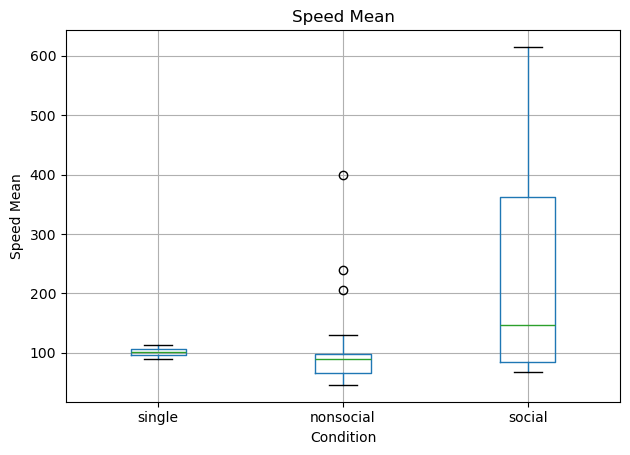

<Figure size 640x480 with 0 Axes>

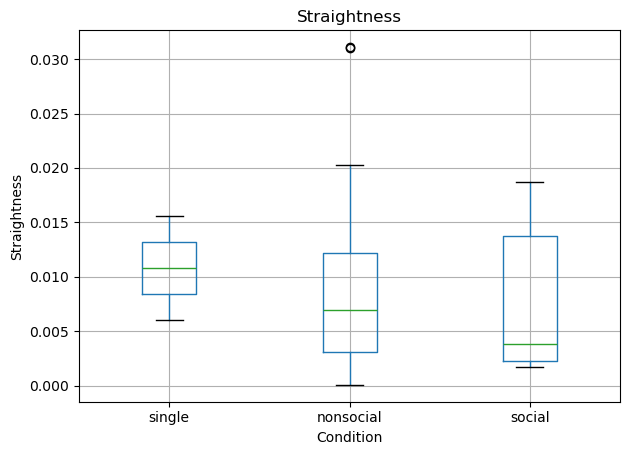

<Figure size 640x480 with 0 Axes>

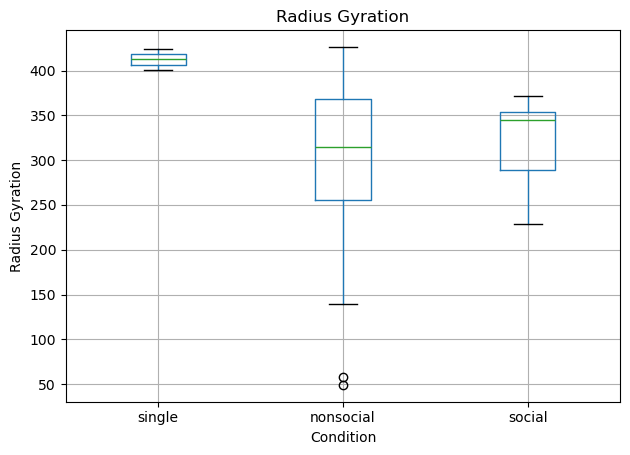

<Figure size 640x480 with 0 Axes>

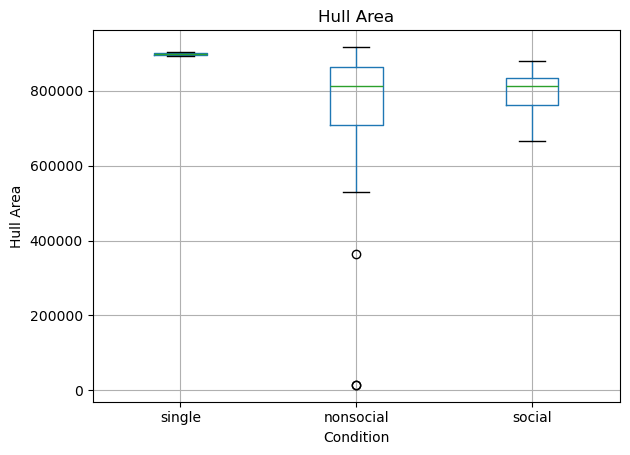

<Figure size 640x480 with 0 Axes>

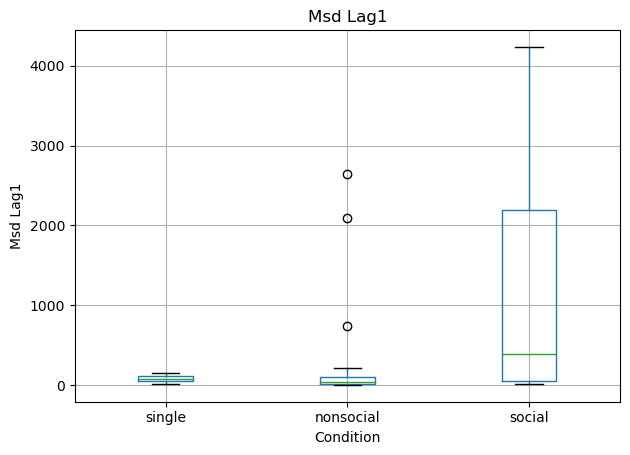

<Figure size 640x480 with 0 Axes>

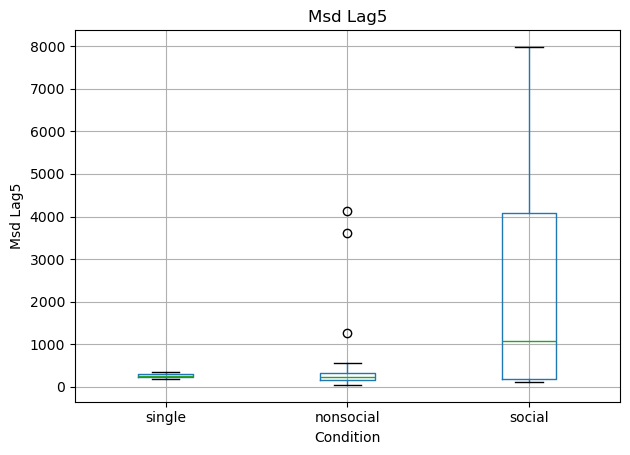

/tmp/ipykernel_500156/3532108006.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby("condition")[metric].mean()
/tmp/ipykernel_500156/3532108006.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds  = df.groupby("condition")[metric].std()


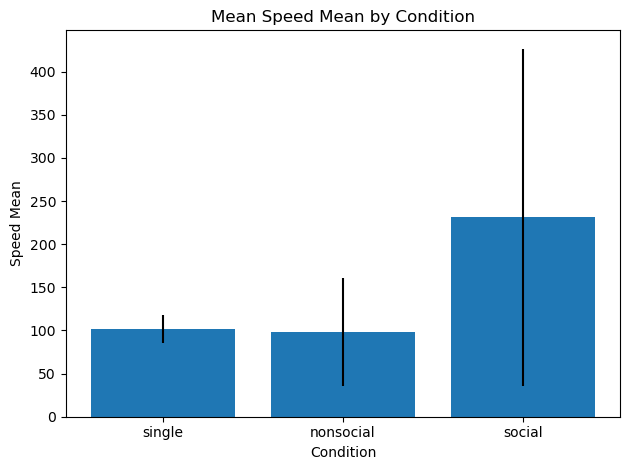

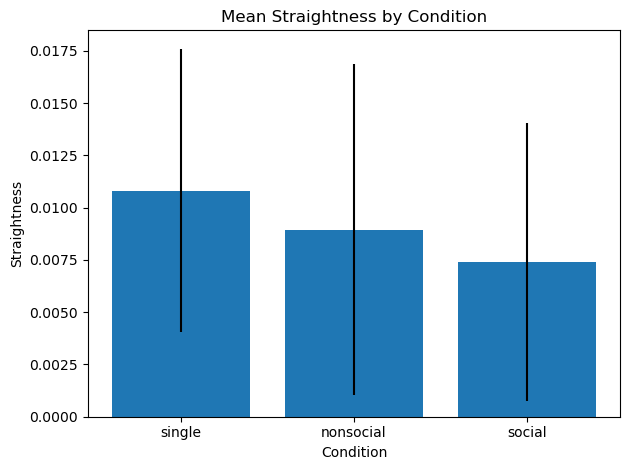

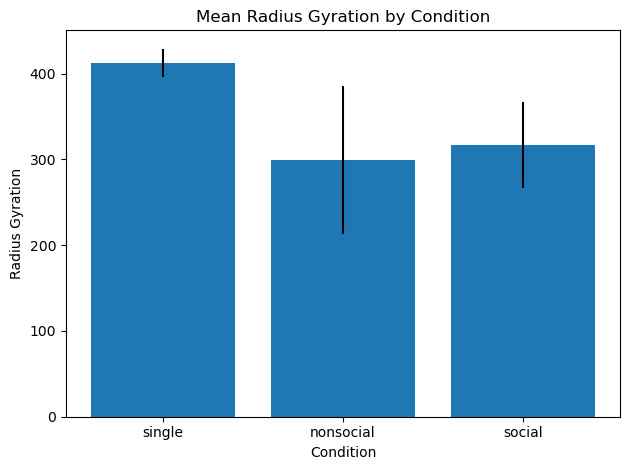

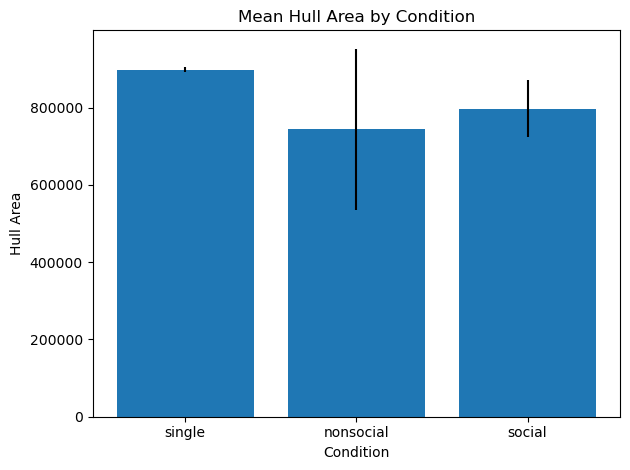

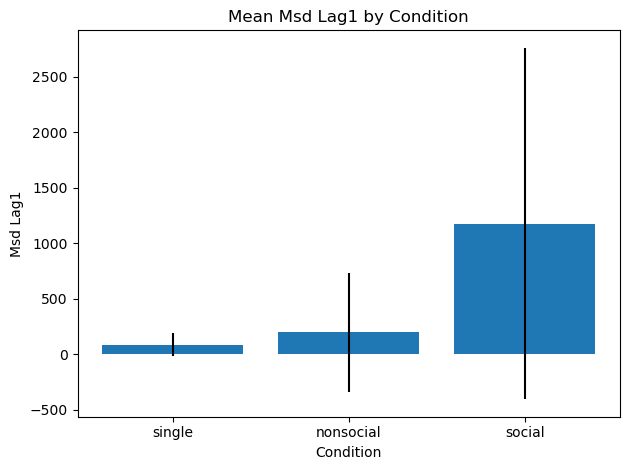

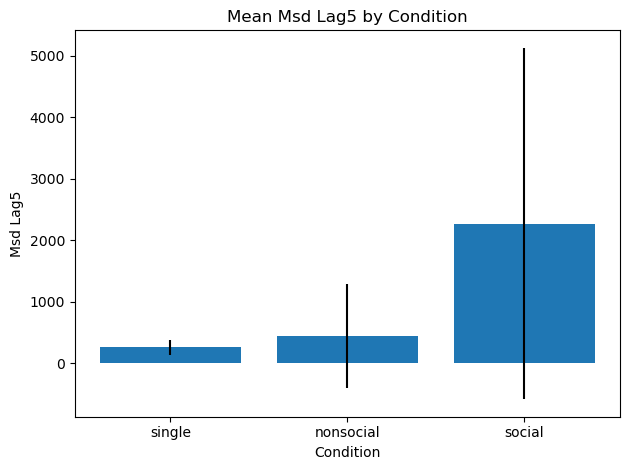

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# if you loaded from CSV:
# df = pd.read_csv("com_movement_by_condition.csv")

# 0) enforce order on the condition column
order = ["single", "nonsocial", "social"]
df["condition"] = pd.Categorical(df["condition"], categories=order, ordered=True)

metrics_to_plot = [
    "speed_mean",
    "straightness",
    "radius_gyration",
    "hull_area",
    "msd_lag1",
    "msd_lag5"
]

# 1) Boxplots in order single → nonsocial → social
for metric in metrics_to_plot:
    plt.figure()
    df.boxplot(column=metric, by="condition")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("Condition")
    plt.ylabel(metric.replace("_", " ").title())
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

# 2) Bar charts of mean ± std in the same order
for metric in metrics_to_plot:
    means = df.groupby("condition")[metric].mean()
    stds  = df.groupby("condition")[metric].std()
    plt.figure()
    plt.bar(means.index, means.values, yerr=stds.values)
    plt.title(f"Mean {metric.replace('_', ' ').title()} by Condition")
    plt.xlabel("Condition")
    plt.ylabel(metric.replace("_", " ").title())
    plt.tight_layout()
    plt.show()


In [18]:
from scipy.stats import f_oneway
import itertools
import pandas as pd
import statsmodels.stats.multitest as smm

def run_anovas(df, metrics, groupby="cup"):
    """
    Perform one-way ANOVA for each metric across the groups in df[groupby].
    Returns a DataFrame with F, p, and Bonferroni-corrected p_adj.
    """
    results = []
    groups = df[groupby].unique()
    for m in metrics:
        # collect values per group
        vals = [df.loc[df[groupby]==g, m].dropna().values for g in groups]
        # only test if at least two groups have >1 sample
        if sum(len(v)>1 for v in vals) > 1:
            F, p = f_oneway(*[v for v in vals if len(v)>1])
        else:
            F, p = float("nan"), float("nan")
        results.append({"metric": m, "F": F, "p": p})
    res = pd.DataFrame(results)
    # multiple testing correction
    res["p_adj"] = smm.multipletests(res["p"].fillna(1), method="bonferroni")[1]
    return res

# usage:
metrics = ["speed_mean", "turn_ang_mean", "straightness", "radius_gyration"]
anova_df = run_anovas(df, metrics, groupby="cup")
print(anova_df)


            metric         F         p  p_adj
0       speed_mean  1.010386  0.446319    1.0
1    turn_ang_mean  0.541837  0.770277    1.0
2     straightness  0.270664  0.944207    1.0
3  radius_gyration  0.389224  0.877214    1.0


/tmp/ipykernel_431006/1767653093.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_in_order, labels=order)


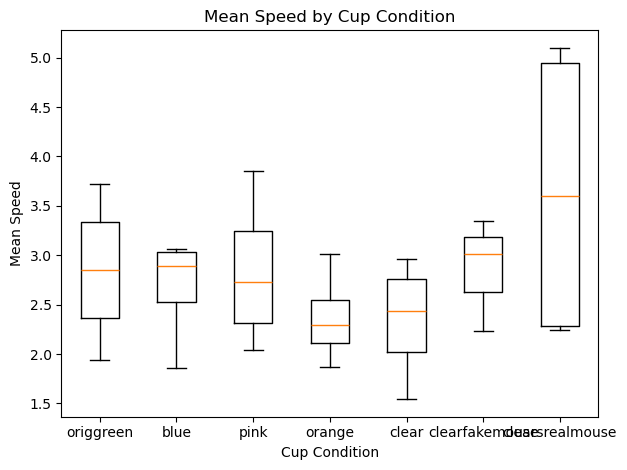

/tmp/ipykernel_431006/1767653093.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_in_order, labels=order)


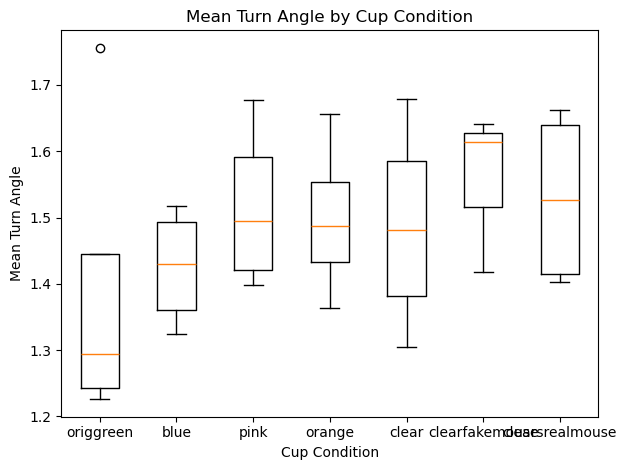

/tmp/ipykernel_431006/1767653093.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_in_order, labels=order)


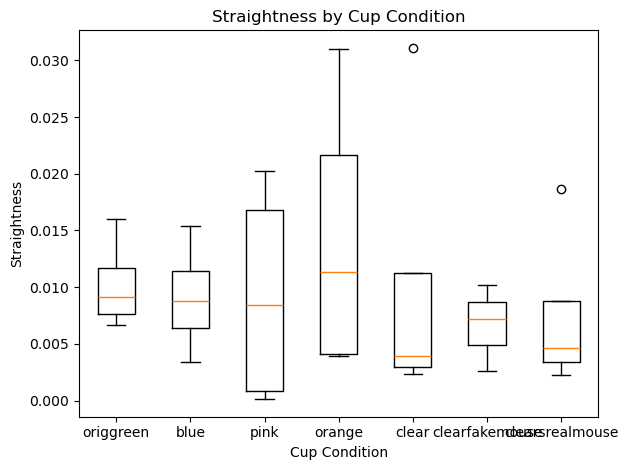

/tmp/ipykernel_431006/1767653093.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_in_order, labels=order)


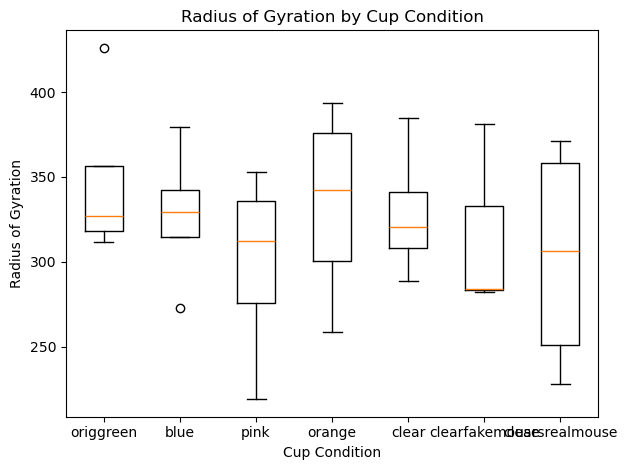

/tmp/ipykernel_431006/1767653093.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_in_order, labels=order)


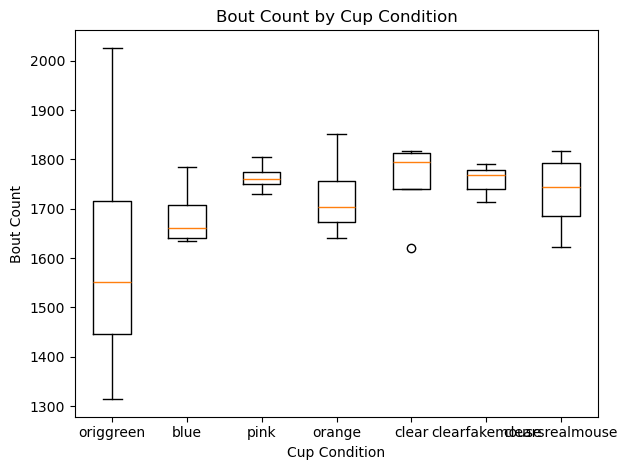

In [22]:
import matplotlib.pyplot as plt

# 1) Define your desired cup order
order = [
    "origgreen",
    "blue",
    "pink",
    "orange",
    "clear",
    "clearfakemouse",
    "clearsrealmouse"
]

# 2) Pick which metrics to visualize (you can add/remove as you like)
metrics = [
    ("Mean Speed",        "speed_mean"),
    ("Mean Turn Angle",   "turn_ang_mean"),
    ("Straightness",      "straightness"),
    ("Radius of Gyration","radius_gyration"),
    ("Bout Count",        "bout_count"),
]

# 3) Loop and plot
for title, col in metrics:
    # gather data in the specified order
    data_in_order = [df.loc[df["cup"] == c, col].dropna().values for c in order]
    
    plt.figure()
    plt.boxplot(data_in_order, labels=order)
    plt.title(f"{title} by Cup Condition")
    plt.xlabel("Cup Condition")
    plt.ylabel(title)
    plt.tight_layout()
    plt.show()


In [ ]:
# Convert and flatten the ChunkedArray
rec_paths = filtered_table["rec_path"].to_pylist()

# Print each path
for path in rec_paths:
    # Each element is likely a list with one string, e.g., ['/some/path']
    print(path[0] if isinstance(path, list) else path)


/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenscup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_clearscup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_greenecup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_greenecup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearscup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_clearecup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250519pmcl2_greenscup
/data/big_rim/rsync_dcc_sum/25juneon/2025_07_08/20250512PMCl23r1_clearecup


In [18]:
#!/usr/bin/env python3
import os
import scipy.io as sio
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
from scipy.stats import f_oneway

# 1. Full list of cup‐only session paths
session_paths = [
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_clear_16_33",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_clearfakemouse_15_11",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_orange_16_23",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_origgreen_14_20",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_pink_16_13",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_blue_16_03",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_clearfakemouse_16_46",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_clearsrealmouse_16_58",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_clearsrealmouse_15_31",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_clear_15_11",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_blue_14_33",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_pink_14_48",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishcap_orange_15_00",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_17/rubbishnocap_origgreen_15_52",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_clearsrealmouse_14_32",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_clearsrealmouse_14_56",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_clearfakemouse_14_32",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_blue_15_41",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_blue_13_49",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_pink_13_59",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_clear_16_47",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_pink_16_00",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_orange_16_23",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_clear_14_20",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_orange_14_10",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival1blkmarktail_origgreen_13_32",
    "/data/big_rim/rsync_dcc_sum/25juneon/2025_07_18/newarrival2_origgreen_15_29"
]
# 2. Cup‐parsing patterns unchanged
cond_patterns = sorted(
    ["clearfakemouse", "clearsrealmouse","origgreen","blue","orange","pink","clear"],
    key=len, reverse=True
)

def parse_metadata(path):
    session = os.path.basename(path)
    date    = os.path.basename(os.path.dirname(path))
    animal  = session.split("_", 1)[0]
    cup     = next((c for c in cond_patterns if c in session), "unknown")
    parts   = session.split("_")
    time    = f"{parts[-2]}:{parts[-1]}" if len(parts)>=2 else "00:00"
    return animal, cup, date, time

def classify_condition_from_cup(cup):
    # only 'clearsrealmouse' is social; everything else (clearfakemouse, origgreen, blue, etc.) is nonsocial
    return "social"    if cup=="clearsrealmouse" else "nonsocial"

def load_com_array(session_path, com_relpath="COM/predict00/com3d0.mat"):
    mat = sio.loadmat(os.path.join(session_path, com_relpath))
    return mat["com"]

records = []
skipped = []

for p in session_paths:
    animal, cup, date, time = parse_metadata(p)
    condition = classify_condition_from_cup(cup)

    try:
        com = load_com_array(p)
    except:
        skipped.append(p)
        continue

    # --- compute all your movement metrics exactly as before ---
    x, y, z = com[:,0], com[:,1], com[:,2]
    mx, sx = x.mean(), x.std(ddof=1)
    my, sy = y.mean(), y.std(ddof=1)
    mz, sz = z.mean(), z.std(ddof=1)

    dxyz       = np.diff(com, axis=0)
    total_dist = np.linalg.norm(dxyz, axis=1).sum()
    dt         = 1/30.0
    speeds     = np.linalg.norm(dxyz, axis=1) / dt

    speed_mean   = speeds.mean()
    speed_median = np.median(speeds)
    speed_std    = speeds.std(ddof=1)
    speed_max    = speeds.max()
    speed_q25    = np.percentile(speeds, 25)
    speed_q75    = np.percentile(speeds, 75)

    net_disp    = np.linalg.norm(com[-1]-com[0])
    straightness = net_disp/total_dist if total_dist>0 else np.nan

    center          = com.mean(axis=0)
    rads            = np.linalg.norm(com-center, axis=1)
    radius_gyration = np.sqrt((rads**2).mean())

    if dxyz.shape[0]>=2:
        v1, v2 = dxyz[:-1], dxyz[1:]
        n1, n2 = np.linalg.norm(v1,axis=1), np.linalg.norm(v2,axis=1)
        valid  = (n1>0)&(n2>0)
        cosang = np.einsum("ij,ij->i", v1[valid], v2[valid])/(n1[valid]*n2[valid])
        angles = np.arccos(np.clip(cosang, -1,1))
        turn_ang_mean = angles.mean()
        turn_ang_std  = angles.std(ddof=1)
    else:
        turn_ang_mean = turn_ang_std = np.nan

    xy = com[:,:2]
    hull_area = ConvexHull(xy).volume if xy.shape[0]>=3 else np.nan

    def msd_at_lag(c, lag):
        return np.mean(np.sum((c[lag:]-c[:-lag])**2,axis=1)) if c.shape[0]>lag else np.nan

    msd1, msd5 = msd_at_lag(com,1), msd_at_lag(com,5)

    records.append({
        "condition":       condition,
        "animal":          animal,
        "cup":             cup,
        "date":            date,
        "time":            time,
        "speed_mean":      speed_mean,
        "speed_median":    speed_median,
        "speed_std":       speed_std,
        "speed_max":       speed_max,
        "speed_q25":       speed_q25,
        "speed_q75":       speed_q75,
        "straightness":    straightness,
        "radius_gyration": radius_gyration,
        "turn_ang_mean":   turn_ang_mean,
        "turn_ang_std":    turn_ang_std,
        "hull_area":       hull_area,
        "msd_lag1":        msd1,
        "msd_lag5":        msd5,
    })

df = pd.DataFrame.from_records(records)

# quick check
print(df["condition"].value_counts(), "\nskipped:", len(skipped), "sessions\n")

# group means
print("Group means by condition:\n",
      df.groupby("condition")[
         ["speed_mean","straightness","radius_gyration","hull_area","msd_lag1","msd_lag5"]
      ].mean(), "\n")

# ANOVA across just social vs. nonsocial
metrics = ["speed_mean","speed_median","speed_std","speed_max",
           "straightness","radius_gyration","hull_area","msd_lag1","msd_lag5"]

print("ANOVA across condition:")
for m in metrics:
    groups = [grp[m].dropna().values
              for _,grp in df.groupby("condition", observed=True)]
    if len(groups)>1:
        F,p = f_oneway(*groups)
        print(f"  {m:15s}  F = {F:6.2f},  p = {p:.3f}")
    else:
        print(f"  {m:15s}  not enough data")


condition
nonsocial    23
social        4
Name: count, dtype: int64 
skipped: 0 sessions

Group means by condition:
            speed_mean  straightness  radius_gyration      hull_area  \
condition                                                             
nonsocial   79.390264      0.010144       326.009465  816737.815078   
social     109.002542      0.007554       303.011253  771474.955546   

            msd_lag1    msd_lag5  
condition                         
nonsocial   59.08906  250.685482  
social     242.77863  621.571545   

ANOVA across condition:
  speed_mean       F =   5.25,  p = 0.031
  speed_median     F =   0.06,  p = 0.805
  speed_std        F =   8.34,  p = 0.008
  speed_max        F =   4.35,  p = 0.047
  straightness     F =   0.31,  p = 0.582
  radius_gyration  F =   0.67,  p = 0.420
  hull_area        F =   1.01,  p = 0.324
  msd_lag1         F =  11.86,  p = 0.002
  msd_lag5         F =   9.43,  p = 0.005


<Figure size 640x480 with 0 Axes>

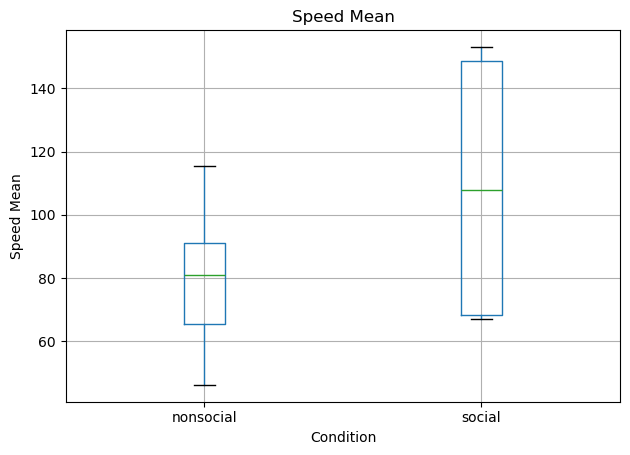

/tmp/ipykernel_500156/1659711430.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_cup.groupby('condition')[metric].mean()
/tmp/ipykernel_500156/1659711430.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds  = df_cup.groupby('condition')[metric].std()


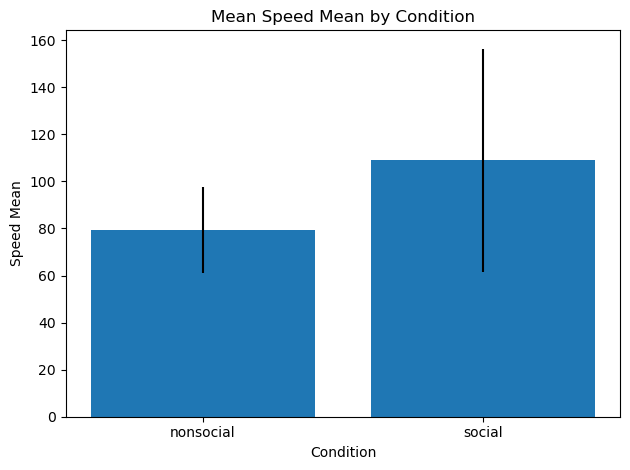

<Figure size 640x480 with 0 Axes>

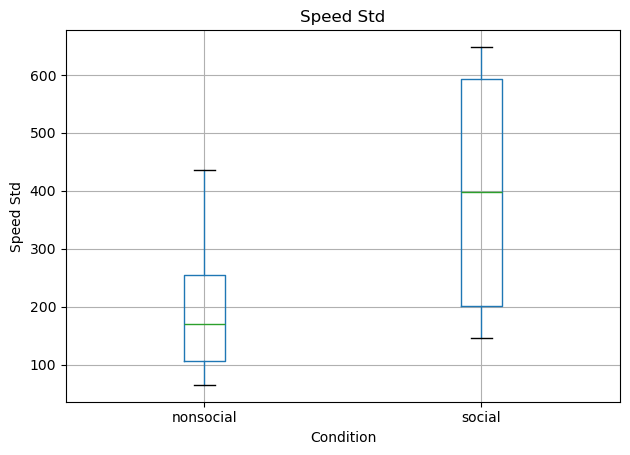

/tmp/ipykernel_500156/1659711430.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_cup.groupby('condition')[metric].mean()
/tmp/ipykernel_500156/1659711430.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds  = df_cup.groupby('condition')[metric].std()


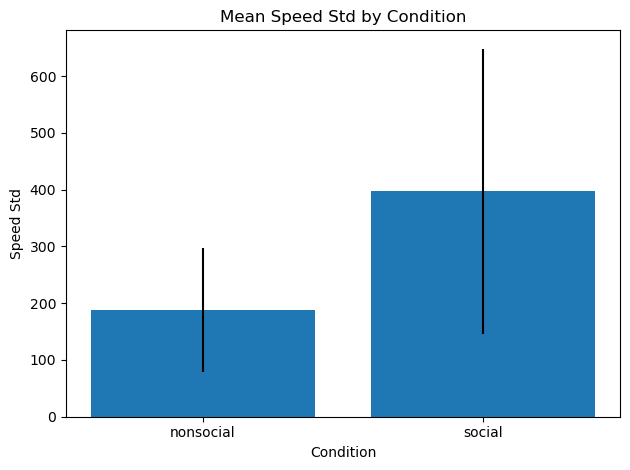

<Figure size 640x480 with 0 Axes>

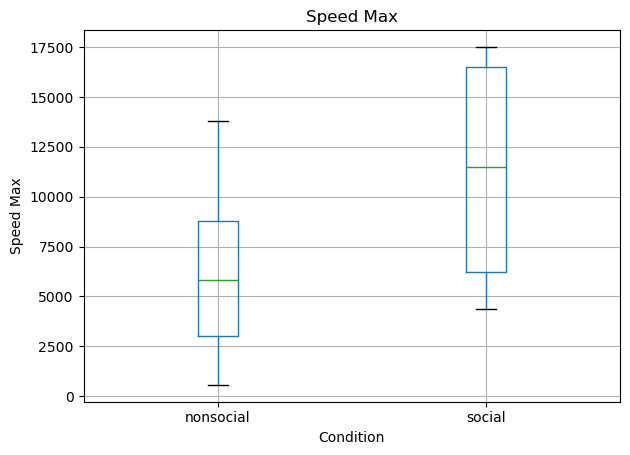

/tmp/ipykernel_500156/1659711430.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_cup.groupby('condition')[metric].mean()
/tmp/ipykernel_500156/1659711430.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds  = df_cup.groupby('condition')[metric].std()


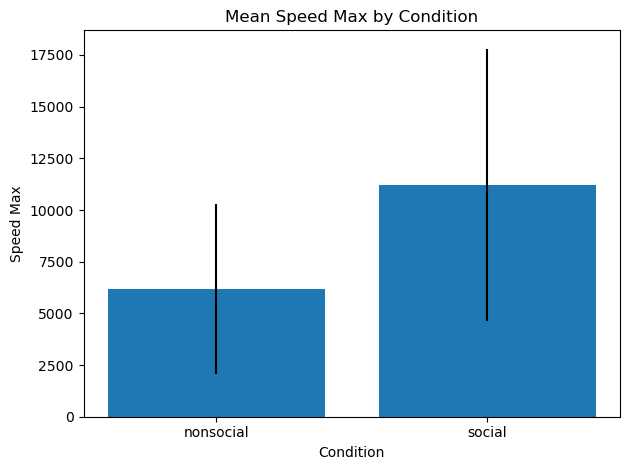

<Figure size 640x480 with 0 Axes>

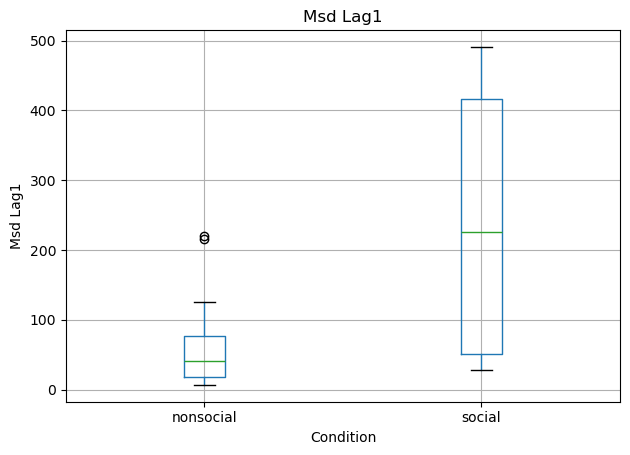

/tmp/ipykernel_500156/1659711430.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_cup.groupby('condition')[metric].mean()
/tmp/ipykernel_500156/1659711430.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds  = df_cup.groupby('condition')[metric].std()


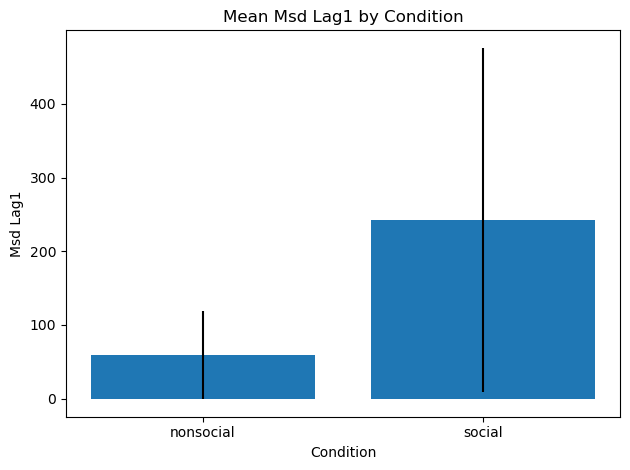

<Figure size 640x480 with 0 Axes>

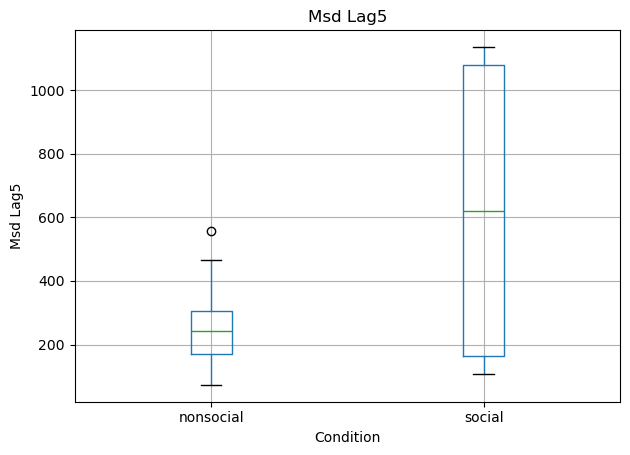

/tmp/ipykernel_500156/1659711430.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df_cup.groupby('condition')[metric].mean()
/tmp/ipykernel_500156/1659711430.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds  = df_cup.groupby('condition')[metric].std()


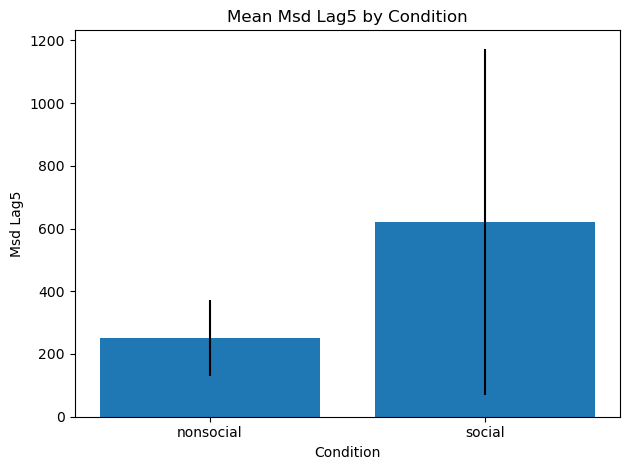

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 0) Reload your results
# df = pd.read_csv("com_movement_by_condition.csv")

# 1) Filter to cup-only social vs. nonsocial
df_cup = df[df['condition'].isin(['social', 'nonsocial'])].copy()

# 2) Set category order
df_cup['condition'] = pd.Categorical(
    df_cup['condition'],
    categories=['nonsocial', 'social'],
    ordered=True
)

# 3) Plot metrics that differed significantly
metrics_to_plot = ['speed_mean', 'speed_std', 'speed_max', 'msd_lag1', 'msd_lag5']

for metric in metrics_to_plot:
    # Boxplot
    plt.figure()
    df_cup.boxplot(column=metric, by='condition')
    plt.title(metric.replace('_', ' ').title())
    plt.suptitle('')
    plt.xlabel('Condition')
    plt.ylabel(metric.replace('_', ' ').title())
    plt.tight_layout()
    plt.show()

    # Bar chart of mean ± std
    means = df_cup.groupby('condition')[metric].mean()
    stds  = df_cup.groupby('condition')[metric].std()
    plt.figure()
    plt.bar(means.index, means.values, yerr=stds.values)
    plt.title(f"Mean {metric.replace('_', ' ').title()} by Condition")
    plt.xlabel('Condition')
    plt.ylabel(metric.replace('_', ' ').title())
    plt.tight_layout()
    plt.show()
